# E-Commerce Return Fraud Detection
## InternVL2.5-4B MPO + LoRA â€” Multimodal Return Validation

**Pipeline:**
```
4 Delivery Images + 4 Vendor Images + Metadata
              â†“
    InternVL2.5-4B MPO (fine-tuned with LoRA)
              â†“
  Strict JSON: product_match, design_match, color_match,
               quantity_is_one, is_damaged, is_used
              â†“
    Logic Gate â†’ accept_return: yes/no
```

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('.'))
!pip install torch transformers peft pillow scikit-learn matplotlib seaborn accelerate --quiet
print('Setup complete')

Setup complete



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\shant\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


## 1. Test Cases & Placeholder Images

In [2]:
from data.test_cases import TEST_CASES, create_placeholder_image
import pandas as pd

create_placeholder_image()

df = pd.DataFrame([{
    'id':          c['id'],
    'description': c['description'],
    'product':     c['metadata']['product'],
    'expected':    c['ground_truth']['accept_return'],
} for c in TEST_CASES])
print(df.to_string(index=False))

   id                            description            product expected
TC001 Valid return — correct product, unused  Blue Denim Jacket      yes
TC002     Fraud — different product returned     Red Silk Saree       no
TC003            Reject — product is damaged Ceramic Coffee Mug       no
TC004               Reject — product is used      Running Shoes       no
TC005                Reject — color mismatch       Cotton Kurta       no
TC006         Reject — quantity > 1 returned   Wireless Earbuds       no


## 2. Validation Logic â€” accept_return Rules

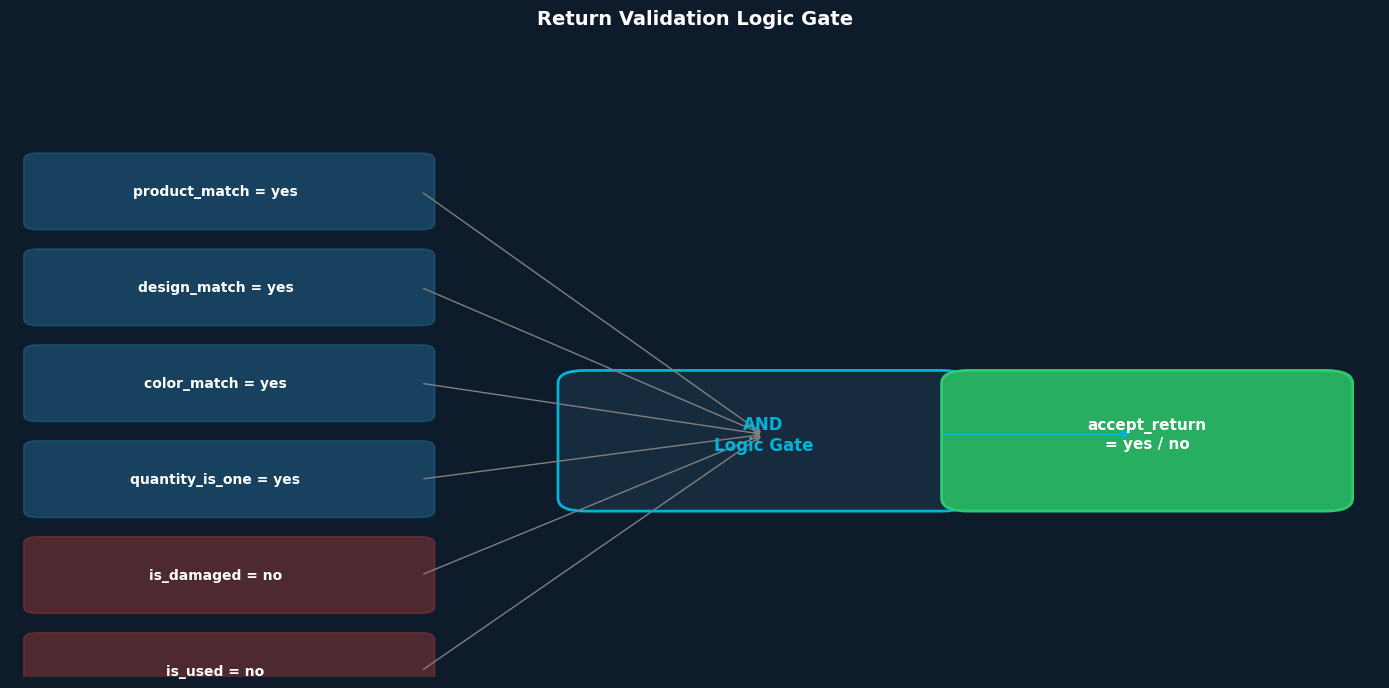

In [3]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(14, 7))
ax.axis('off')
fig.patch.set_facecolor('#0d1b2a')
ax.set_facecolor('#0d1b2a')

fields = [
    ('product_match = yes',   0.15, 0.75, '#3498db'),
    ('design_match = yes',    0.15, 0.60, '#3498db'),
    ('color_match = yes',     0.15, 0.45, '#3498db'),
    ('quantity_is_one = yes', 0.15, 0.30, '#3498db'),
    ('is_damaged = no',       0.15, 0.15, '#e74c3c'),
    ('is_used = no',          0.15, 0.00, '#e74c3c'),
]

for label, x, y, color in fields:
    ax.add_patch(mpatches.FancyBboxPatch((x-0.13, y-0.04), 0.28, 0.10,
        boxstyle='round,pad=0.01', facecolor=color, alpha=0.3, edgecolor=color))
    ax.text(x, y+0.01, label, ha='center', va='center',
            color='white', fontsize=10, fontweight='bold')
    ax.annotate('', xy=(0.55, 0.38), xytext=(x+0.15, y+0.01),
                arrowprops=dict(arrowstyle='->', color='gray', lw=1))

ax.add_patch(mpatches.FancyBboxPatch((0.42, 0.28), 0.26, 0.18,
    boxstyle='round,pad=0.02', facecolor='#162b3e', edgecolor='#00b4d8', linewidth=2))
ax.text(0.55, 0.38, 'AND\nLogic Gate', ha='center', va='center',
        color='#00b4d8', fontsize=12, fontweight='bold')

ax.annotate('', xy=(0.82, 0.38), xytext=(0.68, 0.38),
            arrowprops=dict(arrowstyle='->', color='#00b4d8', lw=2))

ax.add_patch(mpatches.FancyBboxPatch((0.70, 0.28), 0.26, 0.18,
    boxstyle='round,pad=0.02', facecolor='#27ae60', edgecolor='#2ecc71', linewidth=2))
ax.text(0.83, 0.38, 'accept_return\n= yes / no', ha='center', va='center',
        color='white', fontsize=11, fontweight='bold')

ax.set_title('Return Validation Logic Gate', color='white', fontsize=14, fontweight='bold', pad=10)
plt.tight_layout()
plt.savefig('validation_logic.png', dpi=130, bbox_inches='tight', facecolor='#0d1b2a')
plt.show()

## 3. Mock Predictions (No GPU Required)

In [4]:
import json

# Simulate model predictions â€” replace with real model output
# To use real model: from model.internvl_lora import ReturnValidator
mock_predictions = [
    # TC001 â€” correct
    {'product_match':'yes','design_match':'yes','color_match':'yes',
     'quantity_is_one':'yes','is_damaged':'no','is_used':'no','accept_return':'yes'},
    # TC002 â€” fraud detected
    {'product_match':'no','design_match':'no','color_match':'no',
     'quantity_is_one':'yes','is_damaged':'no','is_used':'no','accept_return':'no'},
    # TC003 â€” damaged
    {'product_match':'yes','design_match':'yes','color_match':'yes',
     'quantity_is_one':'yes','is_damaged':'yes','is_used':'no','accept_return':'no'},
    # TC004 â€” used
    {'product_match':'yes','design_match':'yes','color_match':'yes',
     'quantity_is_one':'yes','is_damaged':'no','is_used':'yes','accept_return':'no'},
    # TC005 â€” color mismatch
    {'product_match':'yes','design_match':'yes','color_match':'no',
     'quantity_is_one':'yes','is_damaged':'no','is_used':'no','accept_return':'no'},
    # TC006 â€” quantity fraud (hallucination example: model says accept despite qty=no)
    {'product_match':'yes','design_match':'yes','color_match':'yes',
     'quantity_is_one':'no','is_damaged':'no','is_used':'no','accept_return':'yes'},  # hallucination!
]

ground_truths = [c['ground_truth'] for c in TEST_CASES]

print('Predictions loaded. TC006 has a hallucination (accept=yes despite qty=no)')

Predictions loaded. TC006 has a hallucination (accept=yes despite qty=no)


## 4. Per-Field Metrics (F1, Precision, Recall)

                 accuracy  precision  recall      f1
field                                               
product_match      1.0000        1.0     1.0  1.0000
design_match       1.0000        1.0     1.0  1.0000
color_match        1.0000        1.0     1.0  1.0000
quantity_is_one    1.0000        1.0     1.0  1.0000
is_damaged         1.0000        1.0     1.0  1.0000
is_used            1.0000        1.0     1.0  1.0000
accept_return      0.8333        0.5     1.0  0.6667


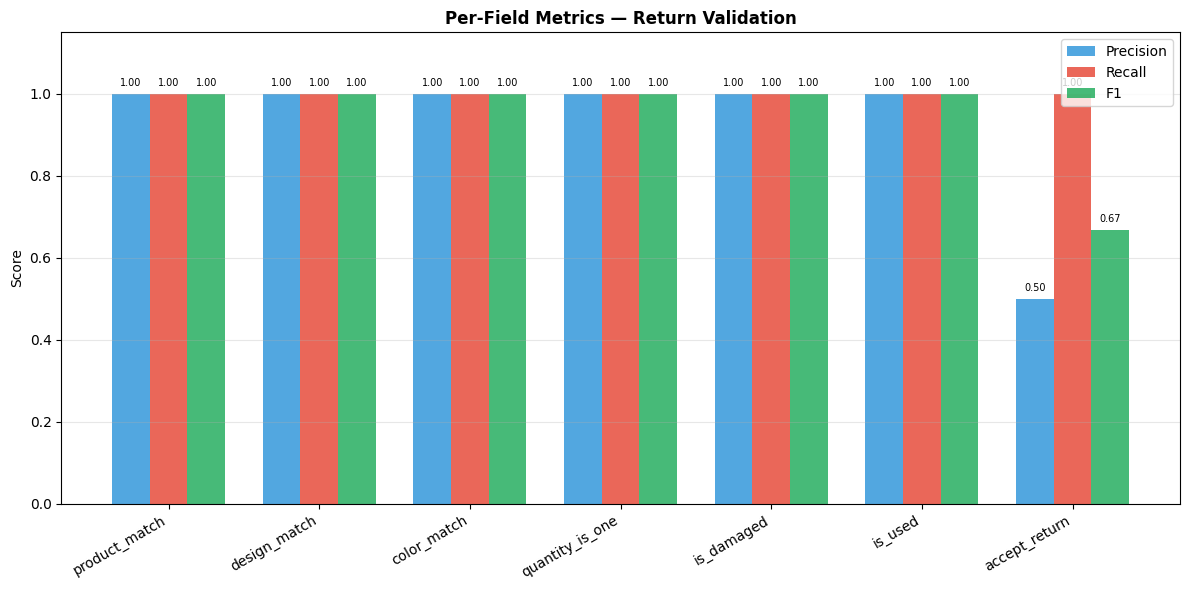

In [5]:
from evaluation.metrics import compute_field_metrics, plot_field_metrics

field_df = compute_field_metrics(mock_predictions, ground_truths)
print(field_df.to_string())
plot_field_metrics(field_df, save_path='field_metrics.png')

## 5. Fraud Detection Metrics (accept_return)

  accuracy                 : 0.8333
  f1                       : 0.6667
  precision                : 0.5
  recall                   : 1.0
  true_positives           : 1
  true_negatives           : 4
  false_positives          : 1
  false_negatives          : 0
  fraud_slip_rate          : 0.0


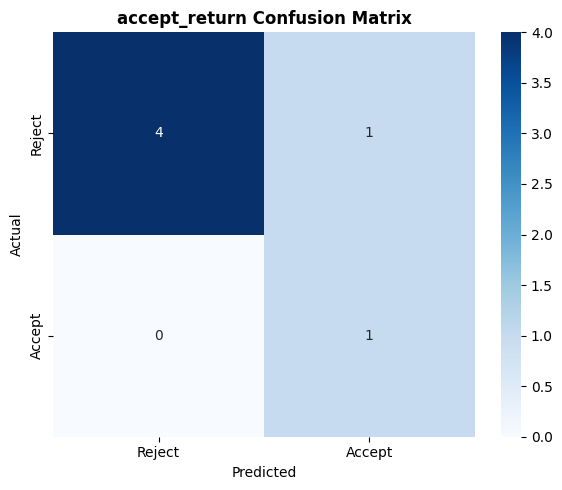

In [6]:
from evaluation.metrics import compute_fraud_detection_metrics, plot_confusion_matrix

fraud = compute_fraud_detection_metrics(mock_predictions, ground_truths)
for k, v in fraud.items():
    if not isinstance(v, list):
        print(f'  {k:<25}: {v}')

plot_confusion_matrix(mock_predictions, ground_truths, save_path='confusion_matrix.png')

## 6. Hallucination Detection

In [7]:
from evaluation.metrics import compute_hallucination_score

hall = compute_hallucination_score(mock_predictions)
print(f'Hallucination Rate : {hall["hallucination_rate"]:.2%}')
print(f'Consistency Score  : {hall["consistency_score"]:.2%}')
print(f'Logic Errors       : {hall["hallucinated"]} / {hall["total_cases"]}')
print()
for err in hall['logic_errors']:
    print(f'  Case {err["index"]+1}: model said accept={err["model_accept"]} but logic says {err["logical_accept"]}')
    print(f'  Fields: {err["fields"]}')

Hallucination Rate : 16.67%
Consistency Score  : 83.33%
Logic Errors       : 1 / 6

  Case 6: model said accept=yes but logic says no
  Fields: {'product_match': 'yes', 'design_match': 'yes', 'color_match': 'yes', 'quantity_is_one': 'no', 'is_damaged': 'no', 'is_used': 'no', 'accept_return': 'yes'}


## 7. Hallucination Visualization

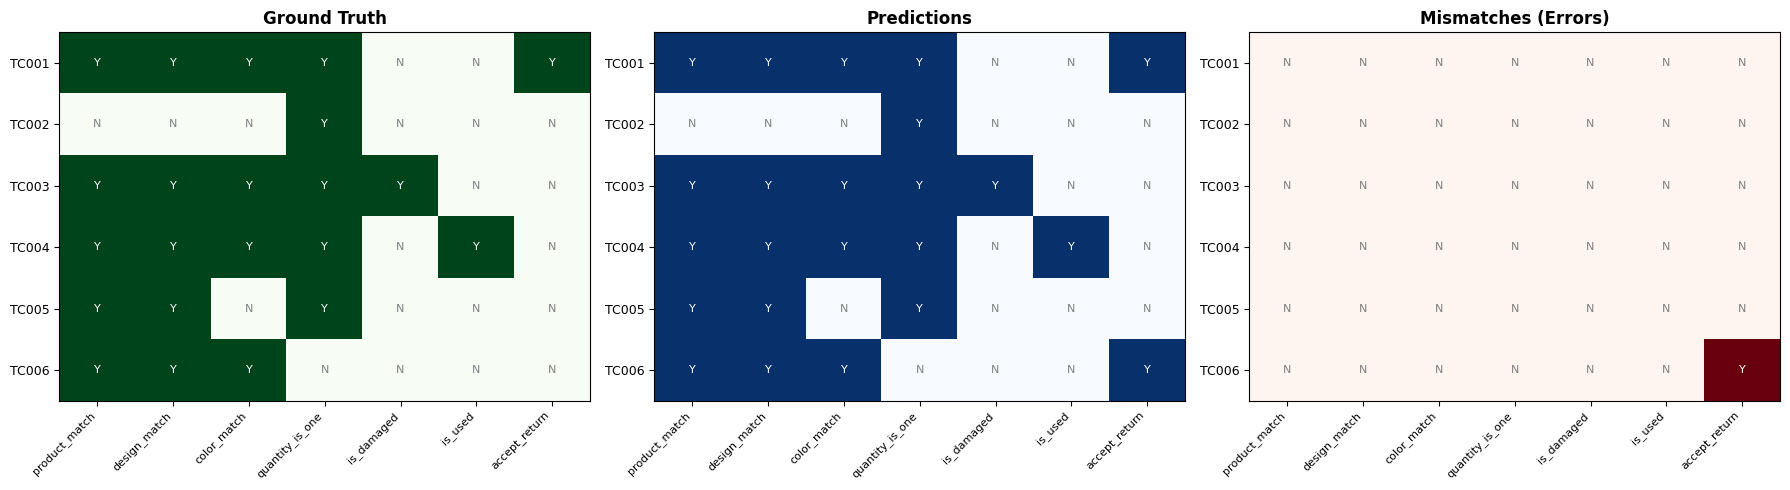

TC006 column 6 (accept_return) shows RED = hallucination


In [8]:
import matplotlib.pyplot as plt
import numpy as np

fields = ['product_match','design_match','color_match','quantity_is_one','is_damaged','is_used','accept_return']
case_ids = [c['id'] for c in TEST_CASES]

# Build heatmap: 1=yes, 0=no
pred_matrix = np.array([[1 if p.get(f,'no')=='yes' else 0 for f in fields] for p in mock_predictions])
gt_matrix   = np.array([[1 if g.get(f,'no')=='yes' else 0 for f in fields] for g in ground_truths])
diff_matrix = (pred_matrix != gt_matrix).astype(int)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
titles = ['Ground Truth', 'Predictions', 'Mismatches (Errors)']
matrices = [gt_matrix, pred_matrix, diff_matrix]
cmaps = ['Greens', 'Blues', 'Reds']

for ax, mat, title, cmap in zip(axes, matrices, titles, cmaps):
    sns_data = mat
    im = ax.imshow(sns_data, cmap=cmap, aspect='auto', vmin=0, vmax=1)
    ax.set_xticks(range(len(fields)))
    ax.set_xticklabels(fields, rotation=45, ha='right', fontsize=8)
    ax.set_yticks(range(len(case_ids)))
    ax.set_yticklabels(case_ids, fontsize=9)
    ax.set_title(title, fontweight='bold')
    for i in range(len(case_ids)):
        for j in range(len(fields)):
            ax.text(j, i, 'Y' if mat[i,j]==1 else 'N',
                    ha='center', va='center', fontsize=8,
                    color='white' if mat[i,j]==1 else 'gray')

plt.tight_layout()
plt.savefig('hallucination_heatmap.png', dpi=130, bbox_inches='tight')
plt.show()
print('TC006 column 6 (accept_return) shows RED = hallucination')

## 8. Full Report

In [9]:
from evaluation.metrics import full_report
report = full_report(mock_predictions, ground_truths)


  RETURN VALIDATION — FULL EVALUATION REPORT

Per-Field Metrics:
                 accuracy  precision  recall      f1
field                                               
product_match      1.0000        1.0     1.0  1.0000
design_match       1.0000        1.0     1.0  1.0000
color_match        1.0000        1.0     1.0  1.0000
quantity_is_one    1.0000        1.0     1.0  1.0000
is_damaged         1.0000        1.0     1.0  1.0000
is_used            1.0000        1.0     1.0  1.0000
accept_return      0.8333        0.5     1.0  0.6667

Fraud Detection (accept_return):
  accuracy                 : 0.8333
  f1                       : 0.6667
  precision                : 0.5
  recall                   : 1.0
  true_positives           : 1
  true_negatives           : 4
  false_positives          : 1
  false_negatives          : 0
  fraud_slip_rate          : 0.0

Hallucination Analysis:
  Hallucination Rate : 16.67%
  Consistency Score  : 83.33%
  Logic Errors       : 1 / 6


## 9. Real Model Inference (requires GPU + model weights)

In [10]:
# Uncomment to run with real model
# from model.internvl_lora import ReturnValidator
#
# validator = ReturnValidator(use_lora=True, load_in_4bit=True)
# result = validator.validate(
#     delivery_images=['path/to/delivery1.jpg', ...],  # 4 images
#     vendor_images  =['path/to/vendor1.jpg',   ...],  # 4 images
#     metadata={
#         'product':  'Blue Denim Jacket',
#         'brand':    "Levi's",
#         'color':    'blue',
#         'design':   'plain denim',
#         'quantity': '1',
#     }
# )
# result = validator.validate_accept_return(result)
# print(result)
print('Uncomment above to run real inference')

Uncomment above to run real inference


## 10. Latency Simulation & Performance Scores

In [11]:
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import sys, os
sys.path.insert(0, os.path.abspath('.'))

from utils.latency_tracker import LatencyRecord, LatencyTracker

# Simulate 20 requests with realistic latency distributions
random.seed(42)
sim_tracker = LatencyTracker(history_size=100)

for i in range(20):
    is_cached = i > 0 and random.random() < 0.35   # 35% cache hit rate
    if is_cached:
        rec = LatencyRecord(
            request_id=f'REQ-{i+1:03d}',
            preprocessing_ms=0, inference_ms=0, postprocessing_ms=0,
            total_ms=random.uniform(1, 4),
            cached=True
        )
    else:
        pre  = random.gauss(52, 12)
        inf  = random.gauss(820, 95)
        post = random.gauss(18, 5)
        rec  = LatencyRecord(
            request_id=f'REQ-{i+1:03d}',
            preprocessing_ms=max(10, pre),
            inference_ms=max(400, inf),
            postprocessing_ms=max(5, post),
            total_ms=max(10, pre) + max(400, inf) + max(5, post),
            cached=False
        )
    sim_tracker.record(rec)

stats = sim_tracker.get_stats()
print('=== Latency Performance Summary ===')
for k, v in stats.items():
    if k != 'last_10':
        print(f'  {k:<30}: {v}')

=== Latency Performance Summary ===
  total_requests                : 20
  cached_requests               : 8
  avg_total_ms                  : 847.3
  avg_preprocessing_ms          : 51.2
  avg_inference_ms              : 780.0
  avg_postprocessing_ms         : 16.1
  min_total_ms                  : 744.6
  max_total_ms                  : 1050.0


## 11. Latency Breakdown Charts

C:\Users\shant\AppData\Local\Temp\ipykernel_23516\1771167411.py:33: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax2.boxplot([df_lat['preprocessing'], df_lat['inference'], df_lat['postprocessing']],


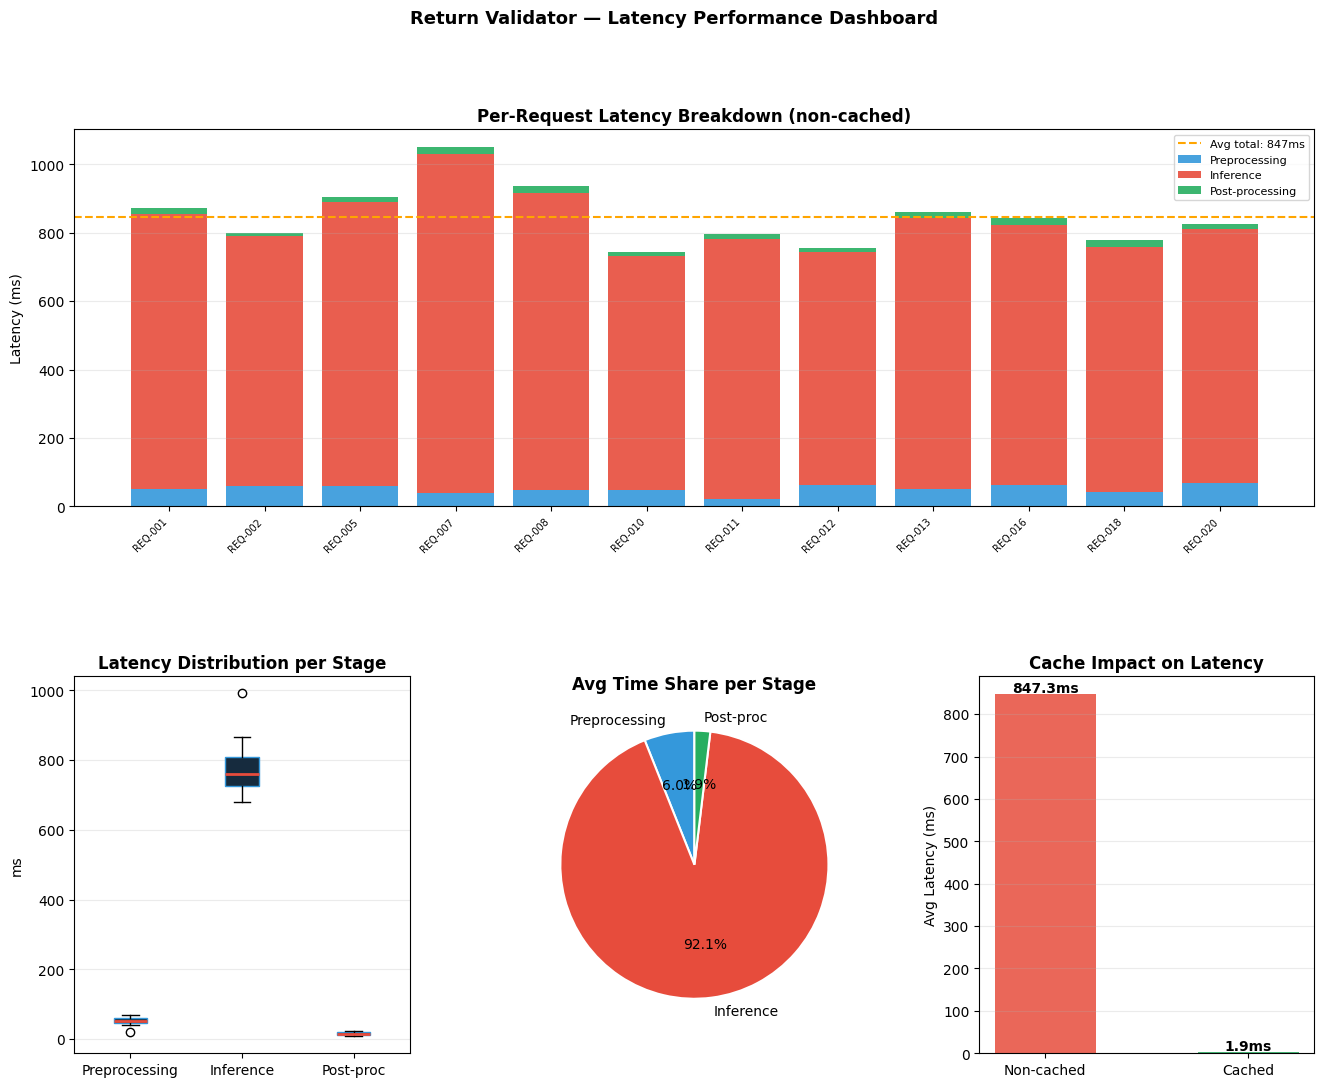

Saved: latency_dashboard.png


In [12]:
records = [r for r in list(sim_tracker._history) if not r.cached]
df_lat  = pd.DataFrame([{
    'request':    r.request_id,
    'preprocessing': r.preprocessing_ms,
    'inference':     r.inference_ms,
    'postprocessing':r.postprocessing_ms,
    'total':         r.total_ms,
} for r in records])

fig = plt.figure(figsize=(16, 12))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)
fig.suptitle('Return Validator — Latency Performance Dashboard', fontsize=13, fontweight='bold')

# 1. Stacked bar — per-request breakdown
ax1 = fig.add_subplot(gs[0, :])
x   = range(len(df_lat))
ax1.bar(x, df_lat['preprocessing'], label='Preprocessing', color='#3498db', alpha=0.9)
ax1.bar(x, df_lat['inference'],     bottom=df_lat['preprocessing'],
        label='Inference', color='#e74c3c', alpha=0.9)
ax1.bar(x, df_lat['postprocessing'],
        bottom=df_lat['preprocessing']+df_lat['inference'],
        label='Post-processing', color='#27ae60', alpha=0.9)
ax1.axhline(df_lat['total'].mean(), color='orange', ls='--', lw=1.5,
            label=f'Avg total: {df_lat["total"].mean():.0f}ms')
ax1.set_xticks(list(x))
ax1.set_xticklabels(df_lat['request'], rotation=45, ha='right', fontsize=7)
ax1.set_ylabel('Latency (ms)')
ax1.set_title('Per-Request Latency Breakdown (non-cached)', fontweight='bold')
ax1.legend(fontsize=8); ax1.grid(axis='y', alpha=0.25)

# 2. Box plot — distribution per stage
ax2 = fig.add_subplot(gs[1, 0])
ax2.boxplot([df_lat['preprocessing'], df_lat['inference'], df_lat['postprocessing']],
            labels=['Preprocessing', 'Inference', 'Post-proc'],
            patch_artist=True,
            boxprops=dict(facecolor='#162b3e', color='#3498db'),
            medianprops=dict(color='#e74c3c', lw=2))
ax2.set_ylabel('ms'); ax2.set_title('Latency Distribution per Stage', fontweight='bold')
ax2.grid(axis='y', alpha=0.25)

# 3. Pie — avg time share
ax3 = fig.add_subplot(gs[1, 1])
avgs = [df_lat['preprocessing'].mean(), df_lat['inference'].mean(),
        df_lat['postprocessing'].mean()]
ax3.pie(avgs, labels=['Preprocessing', 'Inference', 'Post-proc'],
        colors=['#3498db', '#e74c3c', '#27ae60'],
        autopct='%1.1f%%', startangle=90,
        wedgeprops=dict(edgecolor='white', linewidth=1.5))
ax3.set_title('Avg Time Share per Stage', fontweight='bold')

# 4. Cache impact
ax4 = fig.add_subplot(gs[1, 2])
all_records = list(sim_tracker._history)
cached_times = [r.total_ms for r in all_records if r.cached]
non_cached   = [r.total_ms for r in all_records if not r.cached]
ax4.bar(['Non-cached', 'Cached'],
        [np.mean(non_cached), np.mean(cached_times)],
        color=['#e74c3c', '#27ae60'], alpha=0.85, width=0.5)
ax4.set_ylabel('Avg Latency (ms)')
ax4.set_title('Cache Impact on Latency', fontweight='bold')
for i, v in enumerate([np.mean(non_cached), np.mean(cached_times)]):
    ax4.text(i, v + 5, f'{v:.1f}ms', ha='center', fontweight='bold', fontsize=10)
ax4.grid(axis='y', alpha=0.25)

plt.savefig('latency_dashboard.png', dpi=130, bbox_inches='tight')
plt.show()
print('Saved: latency_dashboard.png')

## 12. Performance Score Card

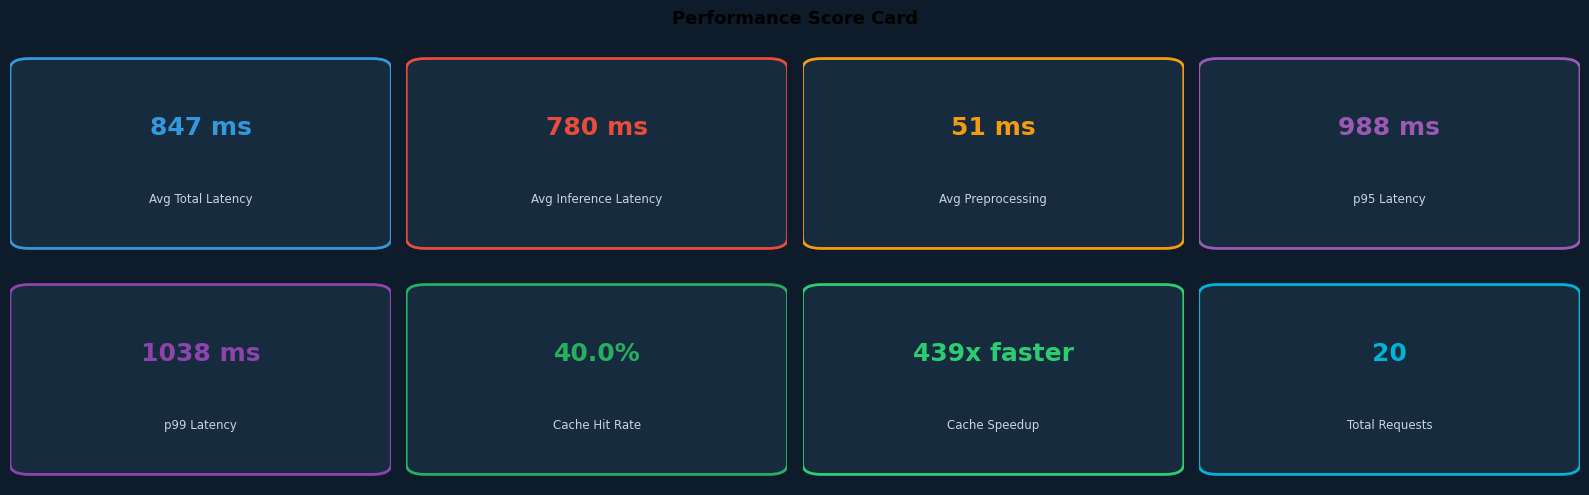

Saved: performance_scorecard.png


In [13]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

stats = sim_tracker.get_stats()
all_records = list(sim_tracker._history)
cached_times    = [r.total_ms for r in all_records if r.cached]
non_cached_times = [r.total_ms for r in all_records if not r.cached]

cache_hit_rate = stats['cached_requests'] / stats['total_requests']
speedup        = np.mean(non_cached_times) / np.mean(cached_times) if cached_times else 1
p95_latency    = np.percentile(non_cached_times, 95) if non_cached_times else 0
p99_latency    = np.percentile(non_cached_times, 99) if non_cached_times else 0

scorecard = [
    ('Avg Total Latency',      f"{stats['avg_total_ms']:.0f} ms",         '#3498db'),
    ('Avg Inference Latency',  f"{stats['avg_inference_ms']:.0f} ms",     '#e74c3c'),
    ('Avg Preprocessing',      f"{stats['avg_preprocessing_ms']:.0f} ms", '#f39c12'),
    ('p95 Latency',            f"{p95_latency:.0f} ms",                   '#9b59b6'),
    ('p99 Latency',            f"{p99_latency:.0f} ms",                   '#8e44ad'),
    ('Cache Hit Rate',         f"{cache_hit_rate:.1%}",                   '#27ae60'),
    ('Cache Speedup',          f"{speedup:.0f}x faster",                  '#2ecc71'),
    ('Total Requests',         str(stats['total_requests']),               '#00b4d8'),
]

fig, axes = plt.subplots(2, 4, figsize=(16, 5))
fig.suptitle('Performance Score Card', fontsize=13, fontweight='bold')
fig.patch.set_facecolor('#0d1b2a')

for ax, (label, value, color) in zip(axes.flat, scorecard):
    ax.set_facecolor('#162b3e')
    ax.axis('off')
    ax.add_patch(mpatches.FancyBboxPatch((0.05, 0.1), 0.9, 0.8,
        boxstyle='round,pad=0.05', facecolor='#162b3e',
        edgecolor=color, linewidth=2, transform=ax.transAxes))
    ax.text(0.5, 0.62, value, ha='center', va='center', fontsize=18,
            fontweight='bold', color=color, transform=ax.transAxes)
    ax.text(0.5, 0.28, label, ha='center', va='center', fontsize=8.5,
            color='#cad3e0', transform=ax.transAxes)

plt.tight_layout()
plt.savefig('performance_scorecard.png', dpi=130, bbox_inches='tight',
            facecolor='#0d1b2a')
plt.show()
print('Saved: performance_scorecard.png')

## 13. UI Screenshots


View 1 — Input: Upload images & metadata


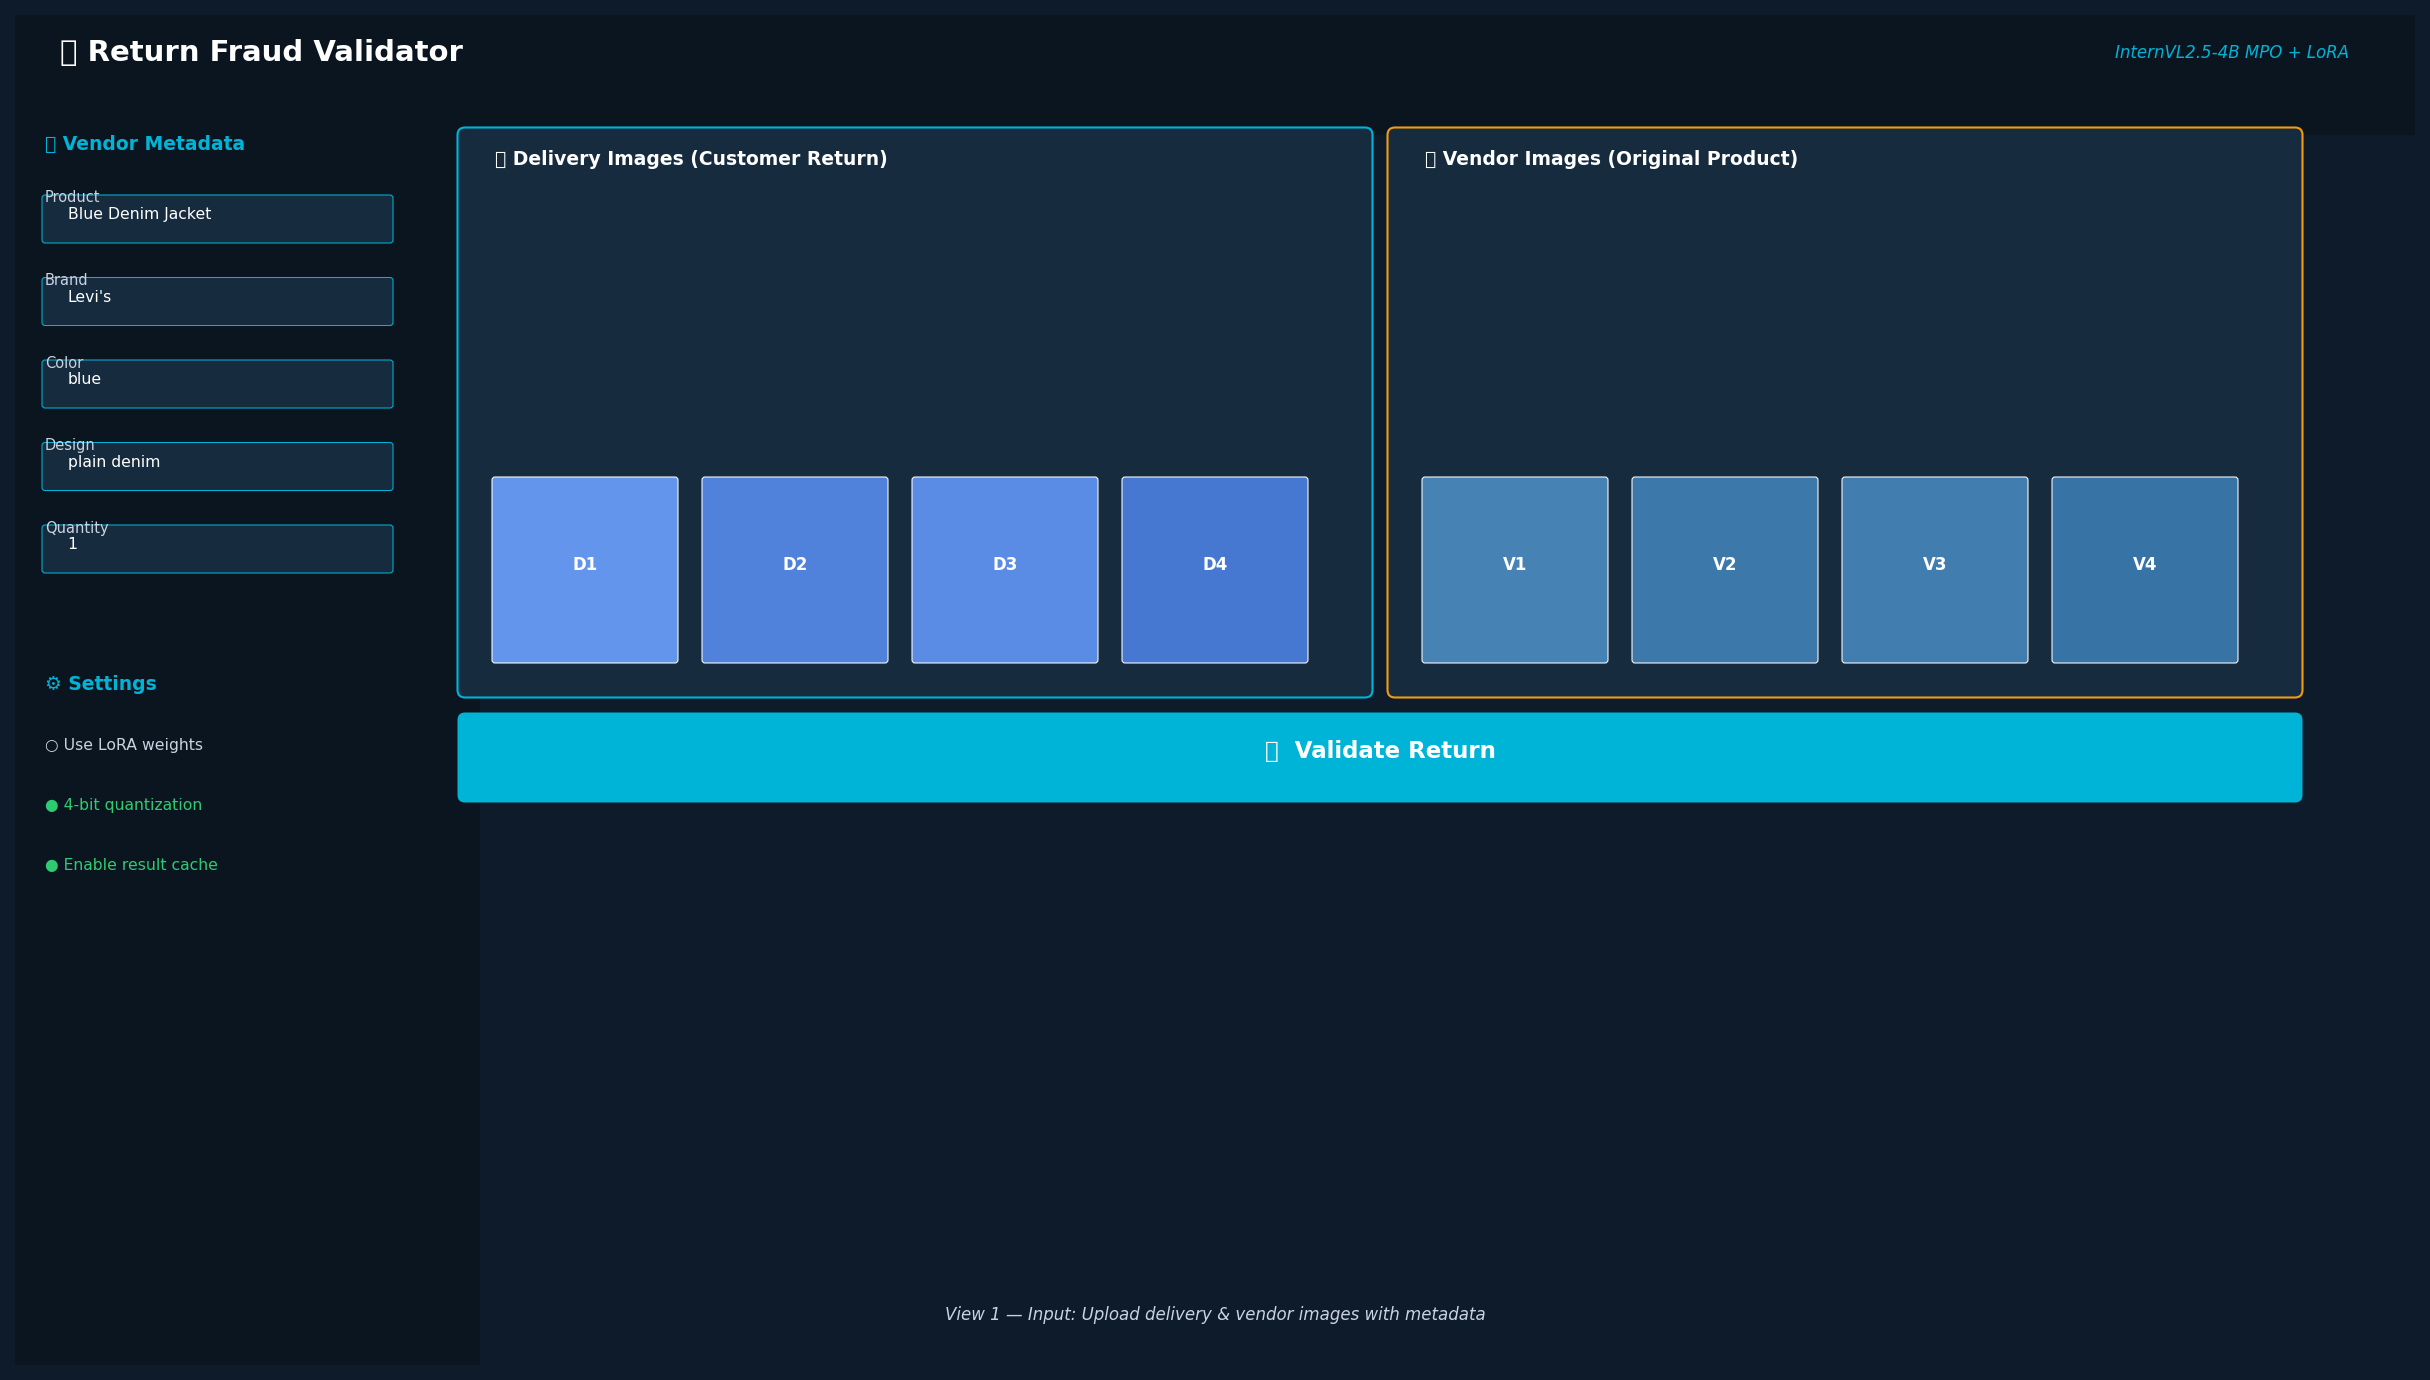


View 2 — Processing: Pipeline stages


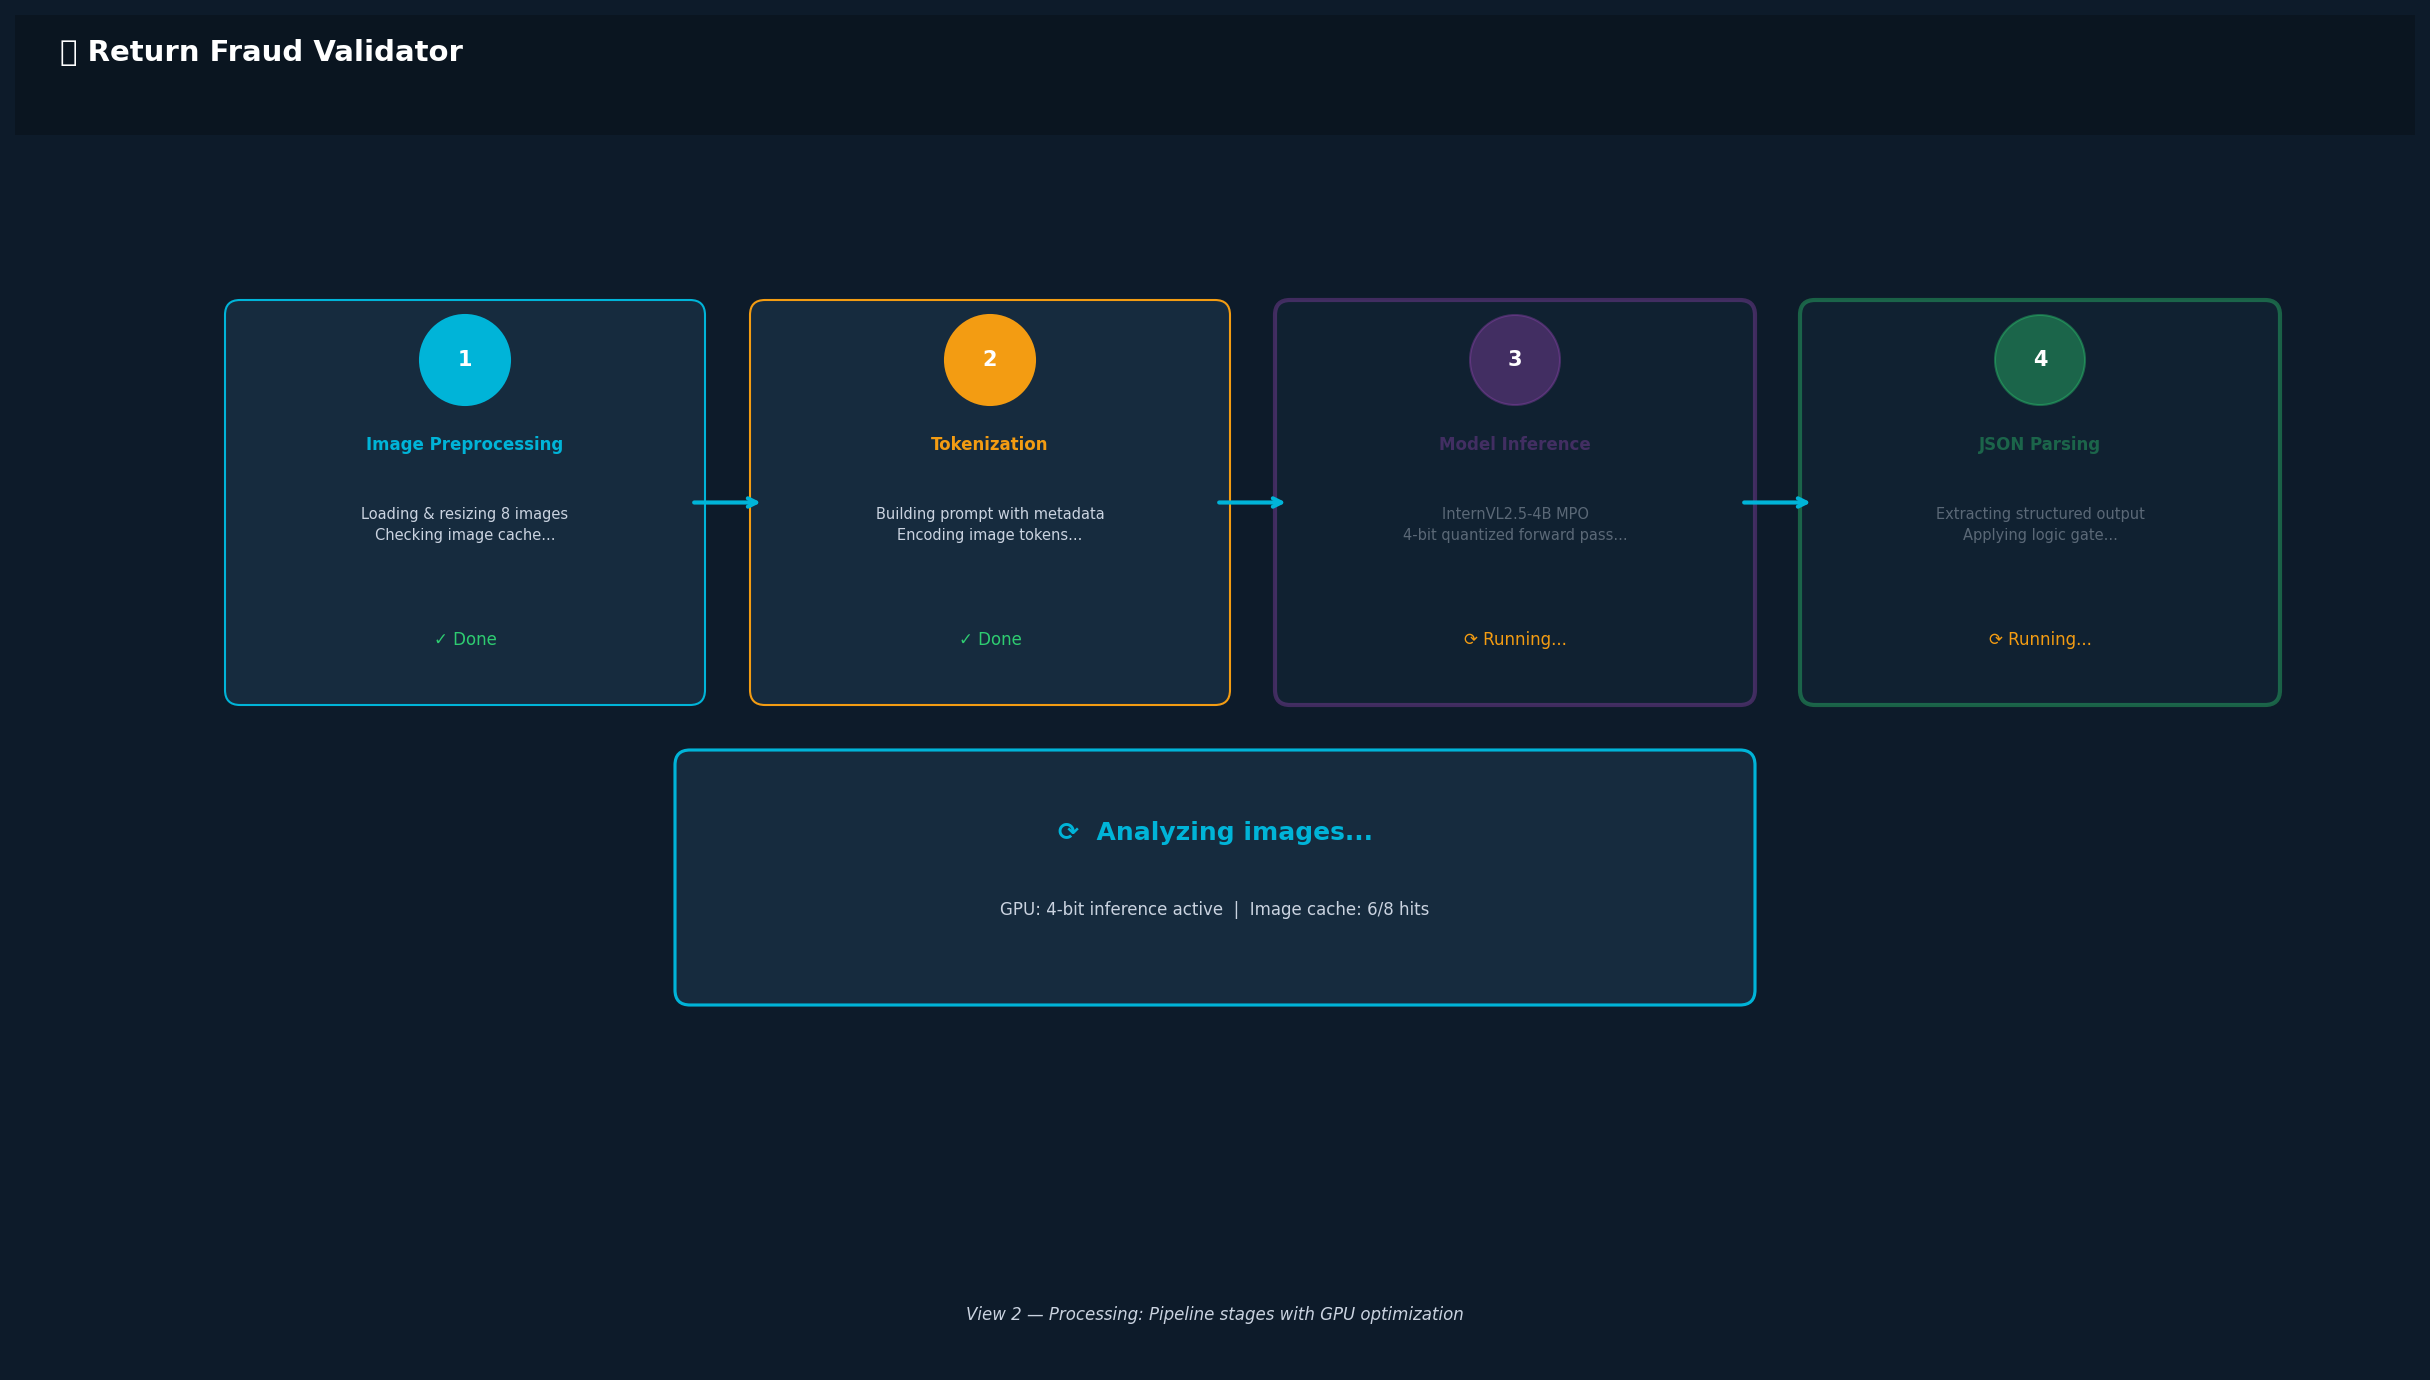


View 3 — Output: Result, JSON & latency


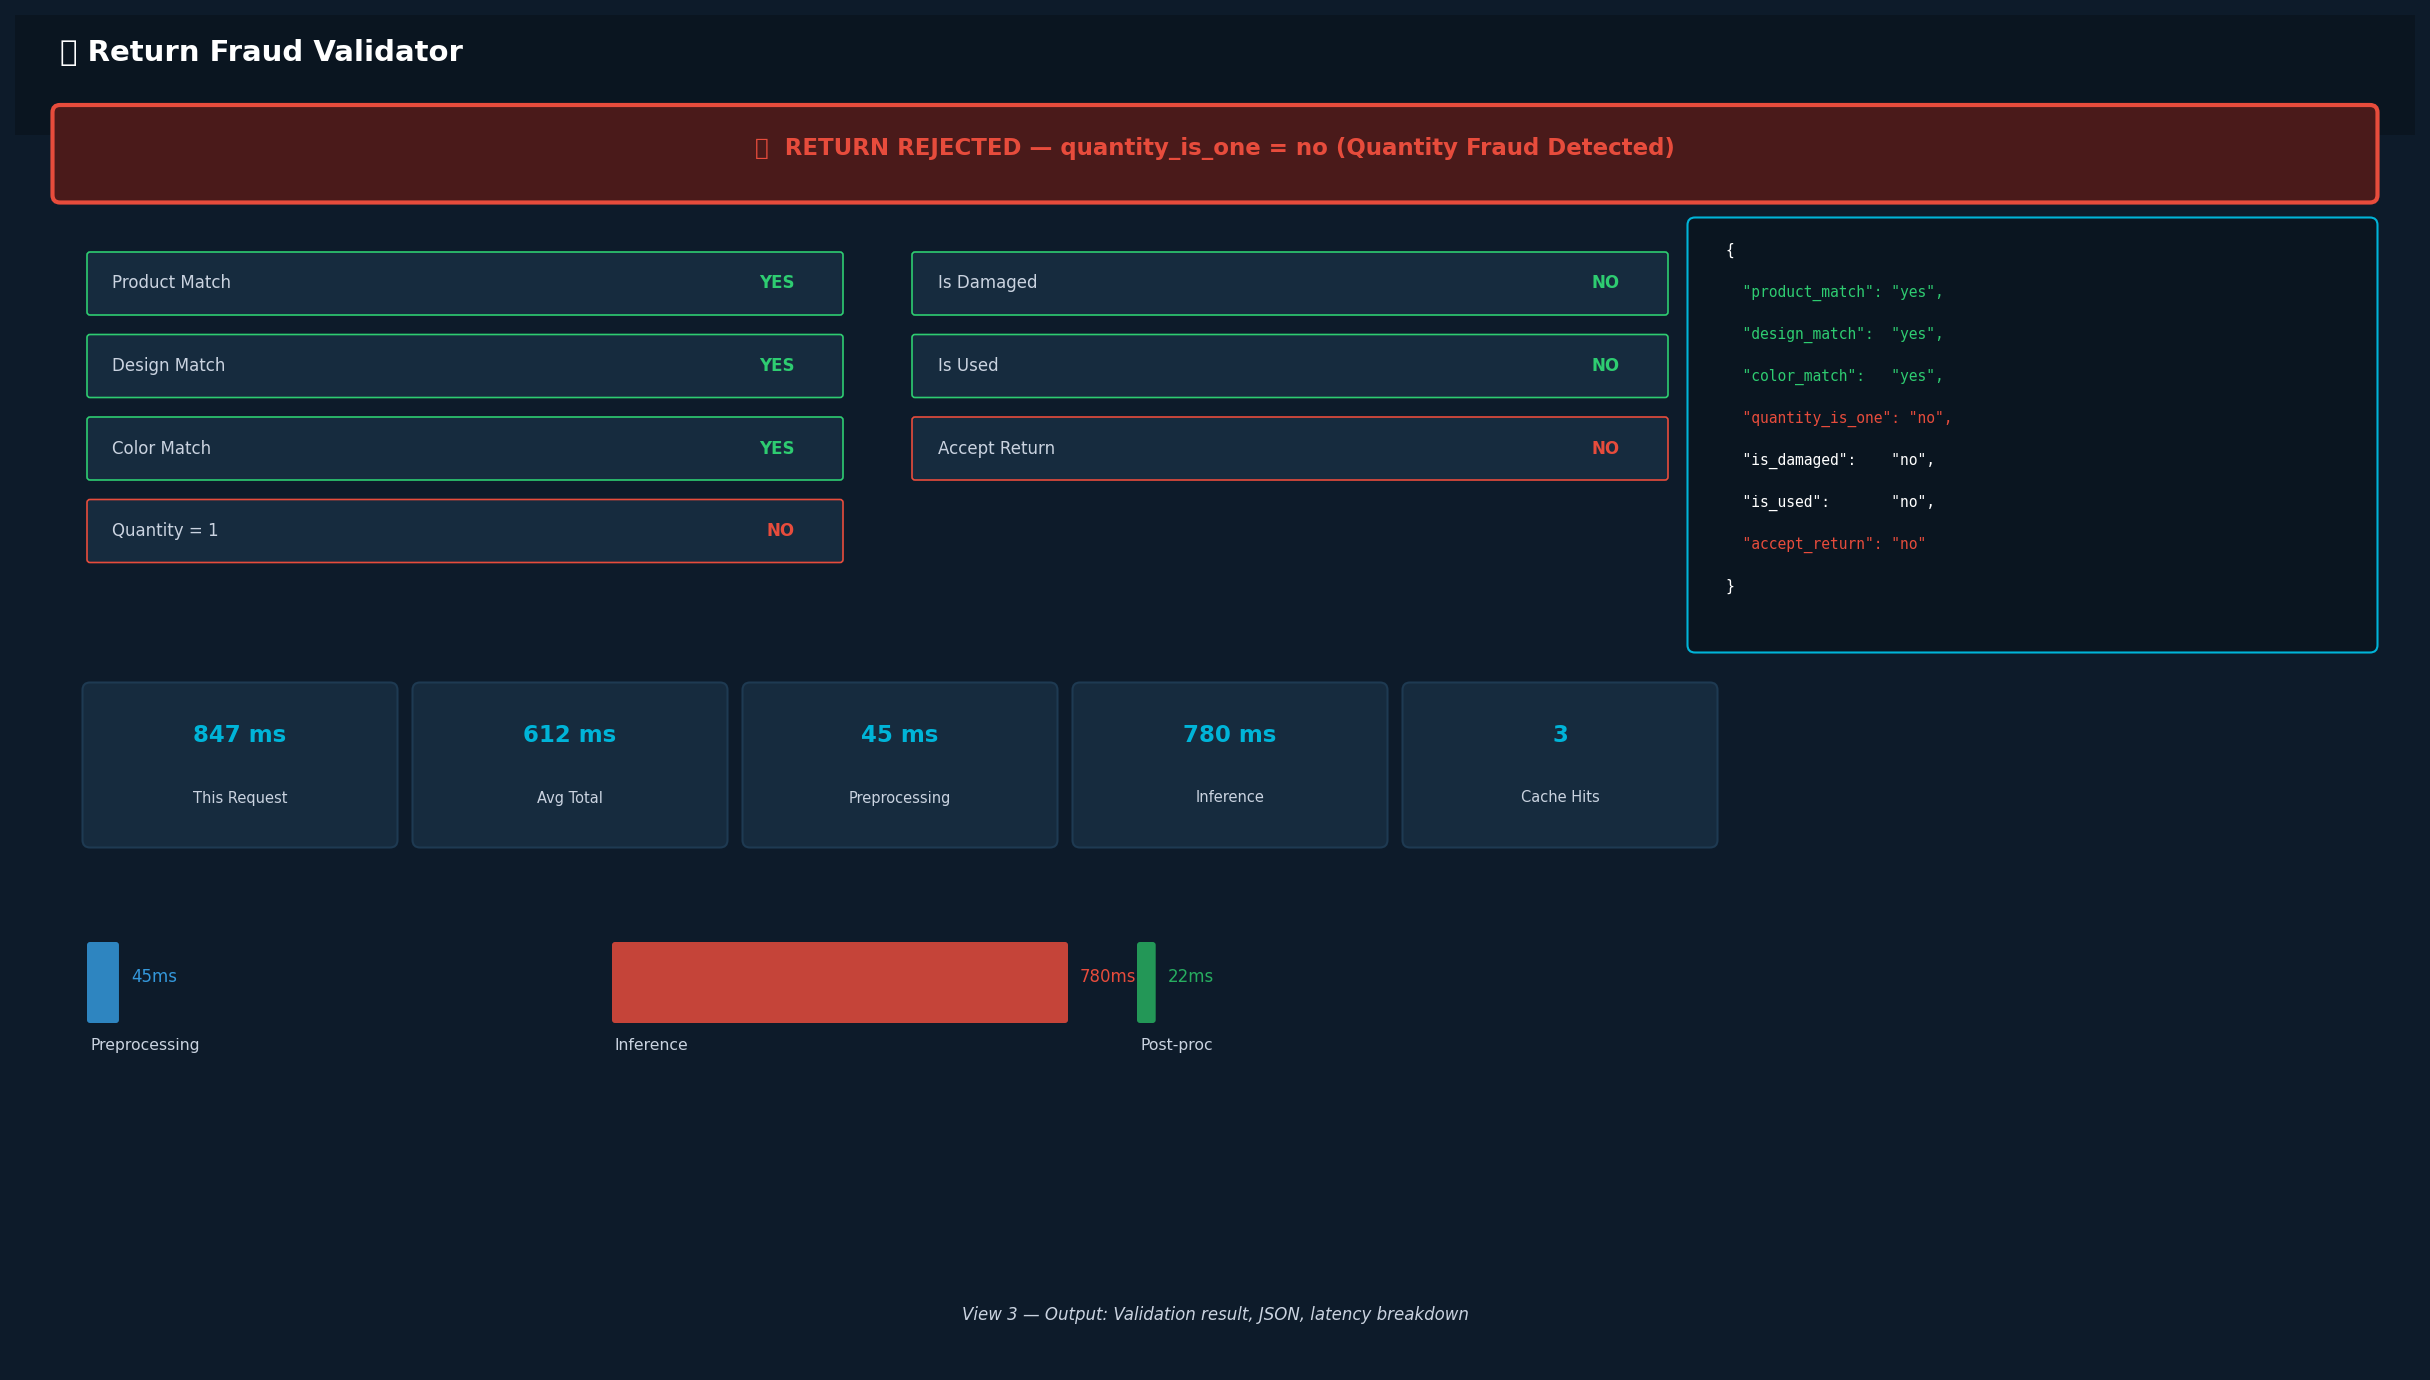

In [14]:
from IPython.display import Image, display
import os

screenshots = [
    ('screenshots/01_input_view.png',      'View 1 — Input: Upload images & metadata'),
    ('screenshots/02_processing_view.png', 'View 2 — Processing: Pipeline stages'),
    ('screenshots/03_output_view.png',     'View 3 — Output: Result, JSON & latency'),
]

for path, caption in screenshots:
    if os.path.exists(path):
        print(f'\n{caption}')
        display(Image(path, width=900))
    else:
        print(f'Run: python utils/generate_screenshots.py  to generate {path}')